# Exercise 3-1: Create some plots

In [3]:
import pandas as pd

## Get the data

In [5]:
mortality_data = pd.read_pickle('mortality_prepped.pkl')
mortality_data.head()

,Year,AgeGroup,DeathRate,MeanCentered
0,1900,01-04 Years,1983.8,1790.87584
1,1901,01-04 Years,1695.0,1502.07584
2,1902,01-04 Years,1655.7,1462.77584
3,1903,01-04 Years,1542.1,1349.17584
4,1904,01-04 Years,1591.5,1398.57584


In [6]:
mortality_wide = pd.read_pickle('mortality_wide.pkl')
mortality_wide.head()

AgeGroup,01-04 Years,05-09 Years,10-14 Years,15-19 Years
Year,,,,
1900,1983.8,466.1,298.3,484.8
1901,1695.0,427.6,273.6,454.4
1902,1655.7,403.3,252.5,421.5
1903,1542.1,414.7,268.2,434.1
1904,1591.5,425.0,305.2,471.4


## Visualize the data

<Axes: xlabel='Year', ylabel='DeathRate'>

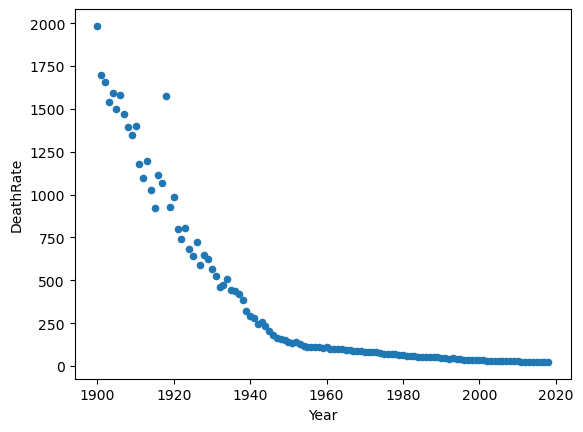

In [8]:
mortality_data.query('AgeGroup == "01-04 Years"').plot.scatter(x='Year', y='DeathRate')

<Axes: xlabel='Year'>

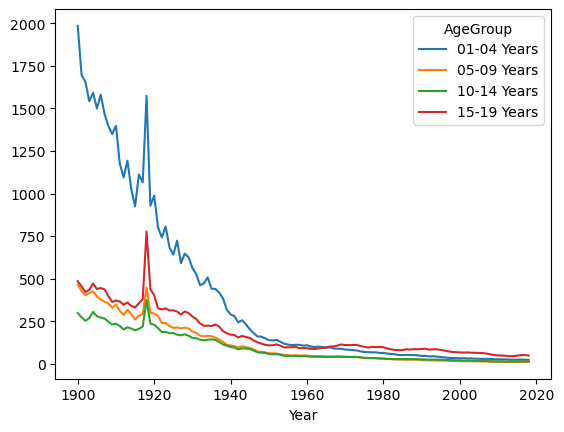

In [9]:
mortality_wide.plot()

# Exercise 3-1 #

## by Jacob Kuhn ##

<Axes: title={'center': '15-19 Years'}, xlabel='Year'>

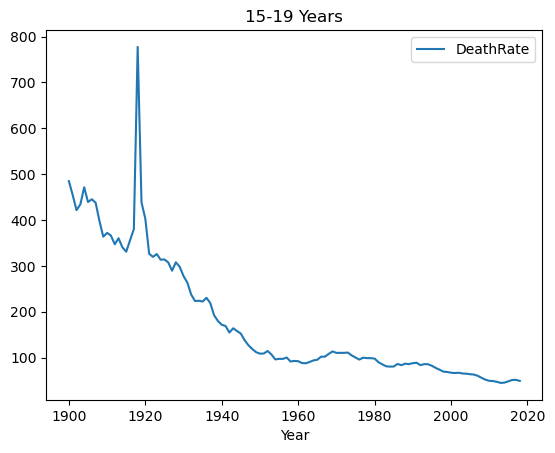

In [13]:
mortality_data.query('AgeGroup == "15-19 Years"').plot.line(title = '15-19 Years', x='Year', y='DeathRate')

<Axes: xlabel='Year'>

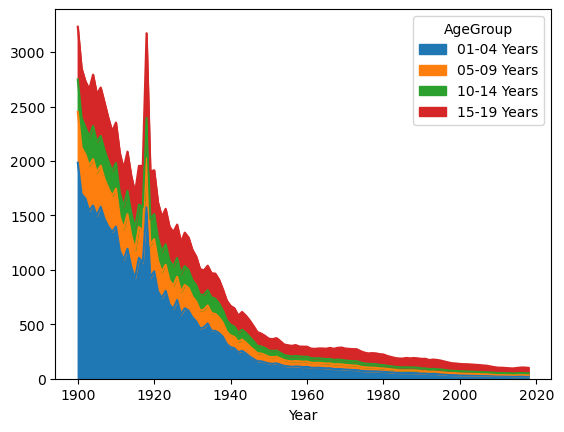

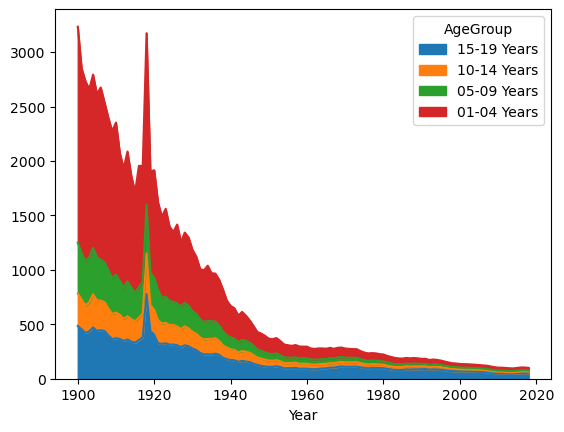

In [14]:
mortality_wide.plot.area()
mortality_wide.plot.area(y=['15-19 Years', '10-14 Years','05-09 Years', '01-04 Years'])

<Axes: title={'center': 'Turn of The Century Youth Mortality'}>

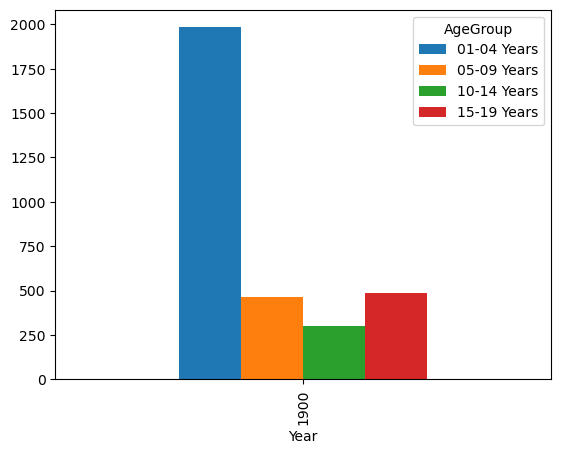

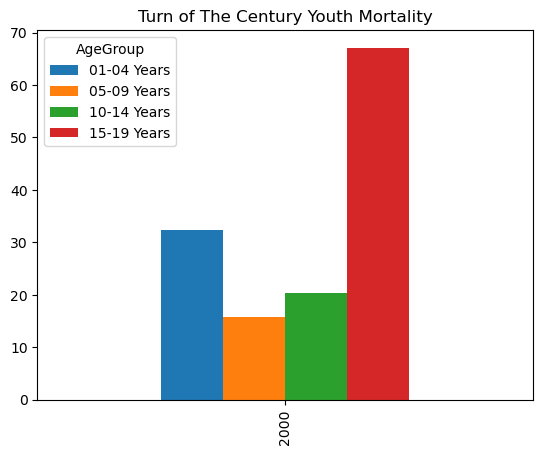

In [15]:
mortality_wide.query('Year in (1900,)').plot.bar()
mortality_wide.query('Year in (2000,)').plot.bar(title = 'Turn of The Century Youth Mortality', xlabel = '')

<Axes: title={'center': 'Turn of The Century Youth Mortality'}>

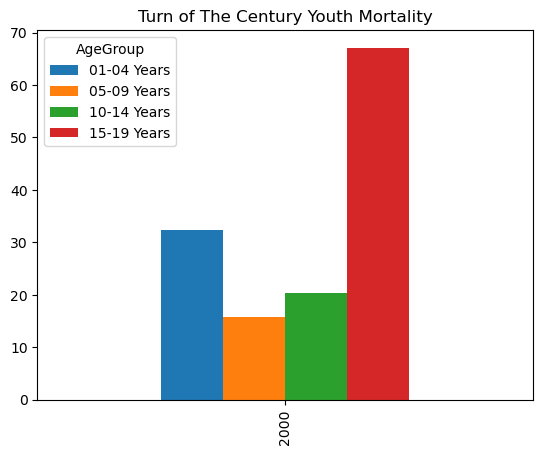

In [16]:
mortality_data.query('Year in (2000,)').pivot(index='Year', columns='AgeGroup', values='DeathRate').plot.bar(title = 'Turn of The Century Youth Mortality', xlabel = '')

<Axes: ylabel='Frequency'>

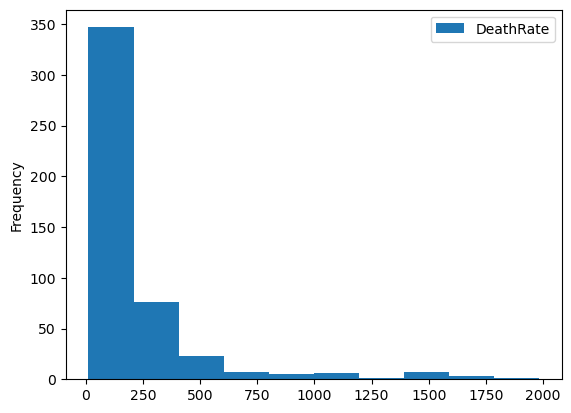

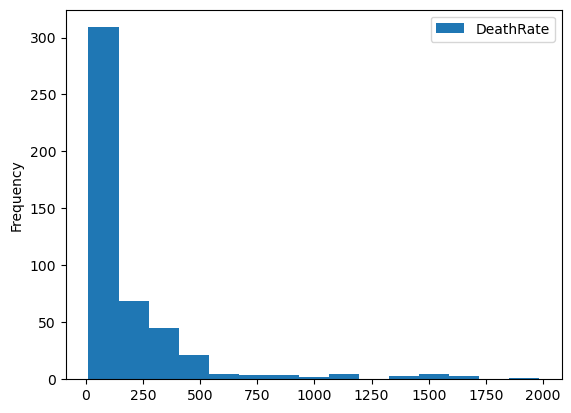

In [17]:
mortality_data.plot.hist(y='DeathRate')
mortality_data.plot.hist(y='DeathRate', bins = 15)

<Axes: title={'center': 'Mortality Density in 1900'}, ylabel='Density'>

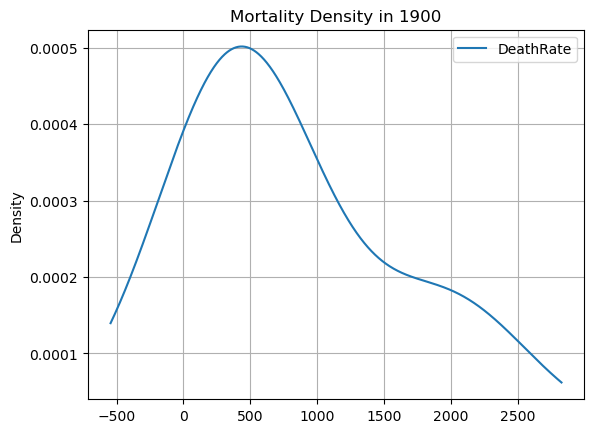

In [18]:
mortality_data.query('Year in (1900,)').plot.density(y='DeathRate',title='Mortality Density in 1900',grid=True)

<Axes: ylabel='DeathRate'>

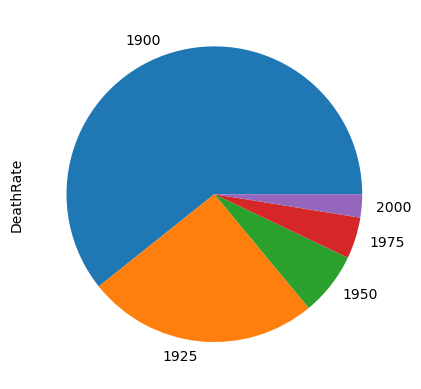

In [19]:

mortality_data.query('Year in (1900, 1925, 1950, 1975, 2000)').groupby('Year')['DeathRate'].sum().plot.pie()

array([[<Axes: title={'center': 'Child Mortality: 01-04'}, xlabel='Death Rate', ylabel='Year'>,
        <Axes: title={'center': 'Child Mortality: 05-09'}, xlabel='Death Rate', ylabel='Year'>],
       [<Axes: title={'center': 'Child Mortality: 10-14'}, xlabel='Death Rate', ylabel='Year'>,
        <Axes: title={'center': 'Child Mortality: 15-19'}, xlabel='Death Rate', ylabel='Year'>]],
      dtype=object)

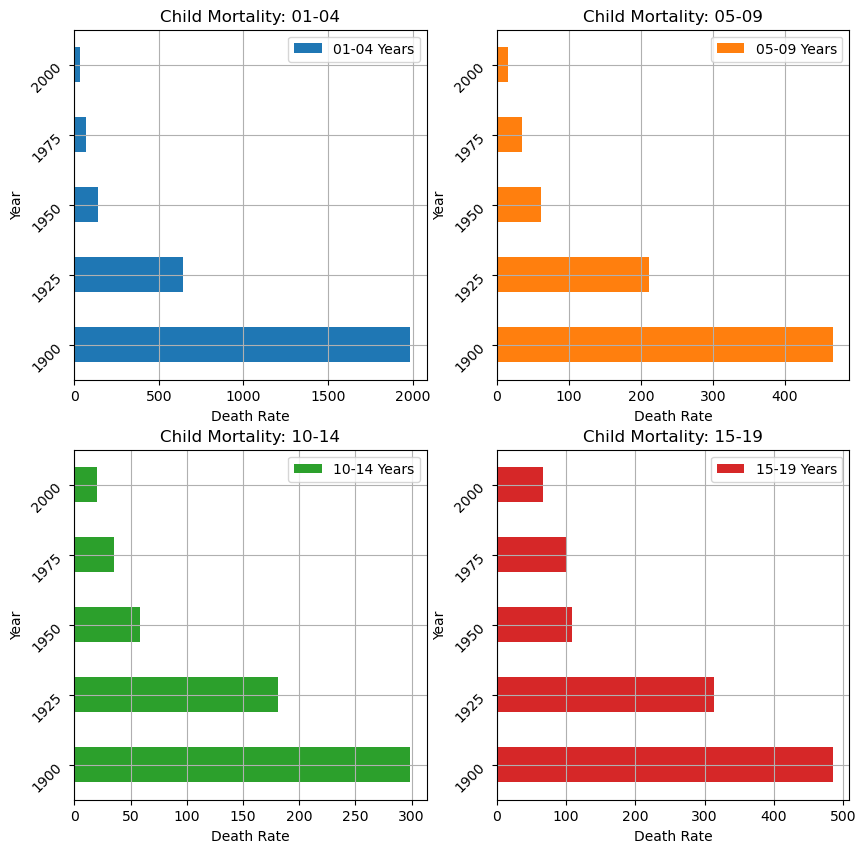

In [20]:
mortality_wide.query('Year in (1900, 1925, 1950, 1975, 2000)').plot.barh(
    title=['Child Mortality: 01-04','Child Mortality: 05-09',
           'Child Mortality: 10-14','Child Mortality: 15-19'],
    ylabel='Year', xlabel= 'Death Rate', sharey=False, sharex=False,
    grid=True, rot=45,
    subplots=True, layout=(2,2), figsize=(10,10))